In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pickle

from imblearn.pipeline import Pipeline as IMBPipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import silhouette_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score

import json

pd.set_option('display.max_columns', None)

In [2]:
df_train = pd.read_csv("data/train_data.csv")
df_train.head()

,year,month,day,order,country,session_id,page1_main_category,page2_clothing_model,colour,location,model_photography,price,price_2,page
0,2008,6,22,21,29,15648,3,C20,13,1,2,48,1,2
1,2008,5,19,6,29,10018,2,B26,13,3,1,57,1,2
2,2008,7,15,2,29,19388,3,C13,9,5,1,48,1,1
3,2008,5,2,2,29,7181,2,B11,2,4,1,43,2,1
4,2008,6,9,16,29,13493,2,B31,9,5,1,57,1,2


In [3]:
country_mapping = {
    1: "Australia", 2: "Austria", 3: "Belgium", 4: "British Virgin Islands", 5: "Cayman Islands",
    6: "Christmas Island", 7: "Croatia", 8: "Cyprus", 9: "Czech Republic", 10: "Denmark",
    11: "Estonia", 12: "unidentified", 13: "Faroe Islands", 14: "Finland", 15: "France",
    16: "Germany", 17: "Greece", 18: "Hungary", 19: "Iceland", 20: "India", 21: "Ireland",
    22: "Italy", 23: "Latvia", 24: "Lithuania", 25: "Luxembourg", 26: "Mexico",
    27: "Netherlands", 28: "Norway", 29: "Poland", 30: "Portugal", 31: "Romania",
    32: "Russia", 33: "San Marino", 34: "Slovakia", 35: "Slovenia", 36: "Spain",
    37: "Sweden", 38: "Switzerland", 39: "Ukraine", 40: "United Arab Emirates",
    41: "United Kingdom", 42: "USA", 43: "biz (.biz)", 44: "com (.com)", 45: "int (.int)",
    46: "net (.net)", 47: "org (*.org)"
}
df_train['country'] = df_train['country'].map(country_mapping)
unwanted_countries = ["biz (.biz)", "com (.com)", "int (.int)", "net (.net)", "org (*.org)"]
df_train = df_train[~df_train['country'].isin(unwanted_countries)]


page1_mapping = {
    1: "trousers", 2: "skirts", 3: "blouses", 4: "sale"
}

colour_mapping = {
    1: "beige", 2: "black", 3: "blue", 4: "brown", 5: "burgundy",
    6: "gray", 7: "green", 8: "navy blue", 9: "of many colors",
    10: "olive", 11: "pink", 12: "red", 13: "violet", 14: "white"
}

location_mapping = {
    1: "top left", 2: "top middle", 3: "top right",
    4: "bottom left", 5: "bottom middle", 6: "bottom right"
}

model_mapping = {
    1: "en face", 2: "profile"
}

# Apply mappings
df_train['page1_main_category'] = df_train['page1_main_category'].map(page1_mapping)
df_train['colour'] = df_train['colour'].map(colour_mapping)
df_train['location'] = df_train['location'].map(location_mapping)
df_train['model_photography'] = df_train['model_photography'].map(model_mapping)


In [4]:
df_train.head(3)

,year,month,day,order,country,session_id,page1_main_category,page2_clothing_model,colour,location,model_photography,price,price_2,page
0,2008,6,22,21,Poland,15648,blouses,C20,violet,top left,profile,48,1,2
1,2008,5,19,6,Poland,10018,skirts,B26,violet,top right,en face,57,1,2
2,2008,7,15,2,Poland,19388,blouses,C13,of many colors,bottom middle,en face,48,1,1


In [5]:
df_train['page2_clothing_model'].unique()

array(['C20', 'B26', 'C13', 'B11', 'B31', 'C38', 'C24', 'C45', 'B24',
       'A11', 'P39', 'P18', 'P16', 'P11', 'A3', 'P1', 'A13', 'C26', 'B17',
       'A7', 'C12', 'A2', 'P2', 'P4', 'C18', 'P3', 'P43', 'C41', 'C10',
       'C25', 'P60', 'P77', 'C33', 'B34', 'P8', 'A25', 'A6', 'B10', 'P12',
       'A30', 'C14', 'C19', 'C40', 'A8', 'A21', 'A22', 'A5', 'C11', 'A16',
       'A29', 'B20', 'C5', 'P55', 'P80', 'P51', 'B25', 'C35', 'C2', 'C17',
       'P14', 'P5', 'A39', 'C7', 'P20', 'P67', 'P49', 'P15', 'C44', 'A14',
       'C9', 'P57', 'A1', 'A38', 'B2', 'P25', 'B27', 'P10', 'P72', 'B32',
       'A33', 'P17', 'C54', 'C56', 'B4', 'A4', 'C27', 'A15', 'C4', 'A17',
       'A41', 'P62', 'A35', 'P48', 'C6', 'A18', 'A37', 'A12', 'P26',
       'P63', 'B14', 'C15', 'P40', 'A36', 'B15', 'P34', 'A42', 'C55',
       'B21', 'P61', 'C8', 'A9', 'P33', 'B8', 'B23', 'B1', 'A10', 'B13',
       'C53', 'P29', 'C16', 'B6', 'P73', 'C50', 'B16', 'A20', 'P42',
       'P74', 'P35', 'A31', 'A26', 'B30', 'P50', 'A28'

In [6]:
df_train.nunique()

year                        1
month                       5
day                        31
order                     193
country                    41
session_id              22063
page1_main_category         4
page2_clothing_model      216
colour                     14
location                    6
model_photography           2
price                      20
price_2                     2
page                        5
dtype: int64

In [7]:
df_train.head()

,year,month,day,order,country,session_id,page1_main_category,page2_clothing_model,colour,location,model_photography,price,price_2,page
0,2008,6,22,21,Poland,15648,blouses,C20,violet,top left,profile,48,1,2
1,2008,5,19,6,Poland,10018,skirts,B26,violet,top right,en face,57,1,2
2,2008,7,15,2,Poland,19388,blouses,C13,of many colors,bottom middle,en face,48,1,1
3,2008,5,2,2,Poland,7181,skirts,B11,black,bottom left,en face,43,2,1
4,2008,6,9,16,Poland,13493,skirts,B31,of many colors,bottom middle,en face,57,1,2


In [8]:
df = df_train.copy()

In [9]:
df['price_2_flag'] = df['price_2'].map({1: 1, 2: 0})

session_data = df.groupby('session_id').agg({
    'order': 'count',       
    'price': 'sum', 
    'year': 'first',
    'month': 'first',
    'day': 'first',                  
    'country': 'first',      
    'page1_main_category': pd.Series.nunique,  
    'page2_clothing_model': pd.Series.nunique, 
    'colour': pd.Series.nunique,
    'location': pd.Series.nunique,
    'model_photography': pd.Series.nunique,
    'price_2': lambda x: 1 if (1 in x.values) else 0,
    'price_2_flag': 'mean',
    'page': pd.Series.nunique      
})

session_data.columns = ['num_of_clicks','Total_revenue','year','month','day','country_of_user','unique_categories','unique_product_models','colour_of_product',
                        'location_of_product','model_photography','price_above_avg','ratio_of_above_avg_price','page_number']

session_data.head()

,num_of_clicks,Total_revenue,year,month,day,country_of_user,unique_categories,unique_product_models,colour_of_product,location_of_product,model_photography,price_above_avg,ratio_of_above_avg_price,page_number
session_id,,,,,,,,,,,,,,
1,8,351,2008,4,1,Poland,4,8,6,6,2,1,0.625000,3
2,9,443,2008,4,1,Poland,3,8,5,6,2,1,0.777778,2
3,3,134,2008,4,1,Ireland,2,3,3,2,2,1,0.666667,1
4,4,181,2008,4,1,Ireland,2,4,2,4,1,1,0.500000,3
5,1,57,2008,4,1,Czech Republic,1,1,1,1,1,1,1.000000,1


In [10]:
session_data = session_data.reset_index()
session_data['purchased'] = df.groupby('session_id')['page1_main_category'].apply(lambda x: 1 if "sale" in x.values else 0).values
session_data.head()

,session_id,num_of_clicks,Total_revenue,year,month,day,country_of_user,unique_categories,unique_product_models,colour_of_product,location_of_product,model_photography,price_above_avg,ratio_of_above_avg_price,page_number,purchased
0,1,8,351,2008,4,1,Poland,4,8,6,6,2,1,0.625000,3,1
1,2,9,443,2008,4,1,Poland,3,8,5,6,2,1,0.777778,2,1
2,3,3,134,2008,4,1,Ireland,2,3,3,2,2,1,0.666667,1,0
3,4,4,181,2008,4,1,Ireland,2,4,2,4,1,1,0.500000,3,0
4,5,1,57,2008,4,1,Czech Republic,1,1,1,1,1,1,1.000000,1,0


In [11]:
session_data['purchased'].value_counts()

purchased
0    13674
1     8389
Name: count, dtype: int64

In [12]:
session_data['date'] = pd.to_datetime(df[['year', 'month', 'day']])

session_data['day_of_week'] = session_data['date'].dt.weekday       # 0 = Monday
session_data['is_weekend'] = session_data['day_of_week'].isin([5,6]).astype(int)
session_data['is_end_of_month'] = (session_data['day'] >= 25).astype(int)
session_data['week_num'] = session_data['date'].dt.isocalendar().week

session_data.head()

,session_id,num_of_clicks,Total_revenue,year,month,day,country_of_user,unique_categories,unique_product_models,colour_of_product,location_of_product,model_photography,price_above_avg,ratio_of_above_avg_price,page_number,purchased,date,day_of_week,is_weekend,is_end_of_month,week_num
0,1,8,351,2008,4,1,Poland,4,8,6,6,2,1,0.625000,3,1,2008-06-22,6.0,1,0,25
1,2,9,443,2008,4,1,Poland,3,8,5,6,2,1,0.777778,2,1,2008-05-19,0.0,0,0,21
2,3,3,134,2008,4,1,Ireland,2,3,3,2,2,1,0.666667,1,0,2008-07-15,1.0,0,0,29
3,4,4,181,2008,4,1,Ireland,2,4,2,4,1,1,0.500000,3,0,2008-05-02,4.0,0,0,18
4,5,1,57,2008,4,1,Czech Republic,1,1,1,1,1,1,1.000000,1,0,2008-06-09,0.0,0,0,24


In [13]:
df_train['click_time'] = pd.to_datetime(df_train[['year', 'month', 'day']]) + pd.to_timedelta(df_train['order'], unit='m')

session_times = df_train.groupby('session_id')['click_time'].agg(['min', 'max']).reset_index()
session_times['session_duration_min'] = (session_times['max'] - session_times['min']).dt.total_seconds() / 60

session_data = pd.merge(session_data, session_times[['session_id', 'session_duration_min']], on='session_id', how='left')

session_data['bounced'] = ((session_data['num_of_clicks'] == 1) & (session_data['purchased'] == 0)).astype(int)

bounce_rate = session_data['bounced'].mean()
print(f"Overall Bounce Rate: {bounce_rate:.2%}")



Overall Bounce Rate: 19.11%


In [14]:

session_data['avg_time_per_click'] = session_data['session_duration_min'] / session_data['num_of_clicks']
session_data['avg_time_per_click'] = session_data['avg_time_per_click'].replace([np.inf, -np.inf], 0).fillna(0)

category_counts = df_train.groupby(['session_id', 'page1_main_category']).size().unstack(fill_value=0)
category_counts.columns = [f'{col}_category_clicks' for col in category_counts.columns]

session_data = pd.merge(session_data, category_counts, on='session_id', how='left')

first_category = df_train.groupby('session_id')['page1_main_category'].first().reset_index()
first_category.columns = ['session_id', 'first_category']
session_data = pd.merge(session_data, first_category, on='session_id', how='left')

def count_category_switches(categories):
    return max((categories != categories.shift()).sum() - 1, 0)

category_switches = df_train.groupby('session_id')['page1_main_category'].apply(count_category_switches).reset_index()
category_switches.columns = ['session_id', 'category_switches']
session_data = pd.merge(session_data, category_switches, on='session_id', how='left')

last_category = df_train.groupby('session_id')['page1_main_category'].last().reset_index()
last_category.columns = ['session_id', 'last_category']
session_data = pd.merge(session_data, last_category, on='session_id', how='left')

model_repeat = df_train.groupby(['session_id', 'page2_clothing_model']).size().reset_index(name='count')
revisited = model_repeat[model_repeat['count'] > 1].groupby('session_id').size().reset_index(name='num_revisits')
session_data = pd.merge(session_data, revisited, on='session_id', how='left')
session_data['num_revisits'] = session_data['num_revisits'].fillna(0)


In [15]:
session_data.head()

,session_id,num_of_clicks,Total_revenue,year,month,day,country_of_user,unique_categories,unique_product_models,colour_of_product,location_of_product,model_photography,price_above_avg,ratio_of_above_avg_price,page_number,purchased,date,day_of_week,is_weekend,is_end_of_month,week_num,session_duration_min,bounced,avg_time_per_click,blouses_category_clicks,sale_category_clicks,skirts_category_clicks,trousers_category_clicks,first_category,category_switches,last_category,num_revisits
0,1,8,351,2008,4,1,Poland,4,8,6,6,2,1,0.625000,3,1,2008-06-22,6.0,1,0,25,7.0,0,0.875000,2,2,3,1,skirts,5,blouses,0.0
1,2,9,443,2008,4,1,Poland,3,8,5,6,2,1,0.777778,2,1,2008-05-19,0.0,0,0,21,9.0,0,1.000000,0,3,4,2,trousers,5,skirts,1.0
2,3,3,134,2008,4,1,Ireland,2,3,3,2,2,1,0.666667,1,0,2008-07-15,1.0,0,0,29,4.0,0,1.333333,2,0,1,0,blouses,1,skirts,0.0
3,4,4,181,2008,4,1,Ireland,2,4,2,4,1,1,0.500000,3,0,2008-05-02,4.0,0,0,18,3.0,0,0.750000,2,0,0,2,trousers,3,blouses,0.0
4,5,1,57,2008,4,1,Czech Republic,1,1,1,1,1,1,1.000000,1,0,2008-06-09,0.0,0,0,24,0.0,1,0.000000,1,0,0,0,blouses,0,blouses,0.0


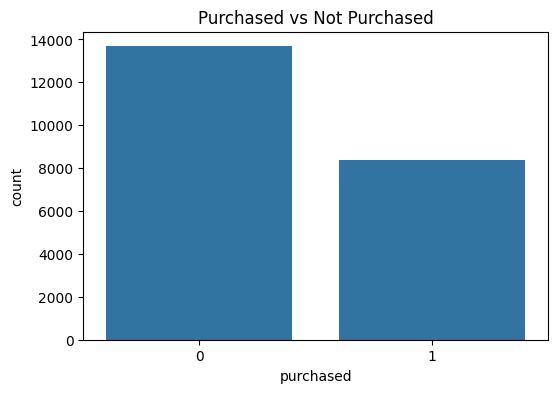

In [16]:

plt.figure(figsize=(6,4))
sns.countplot(data=session_data, x='purchased')
plt.title("Purchased vs Not Purchased")
plt.show()

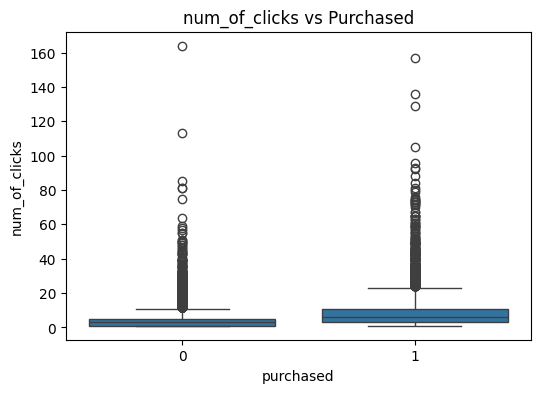

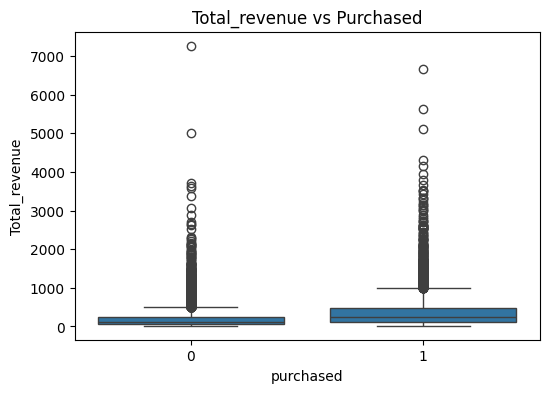

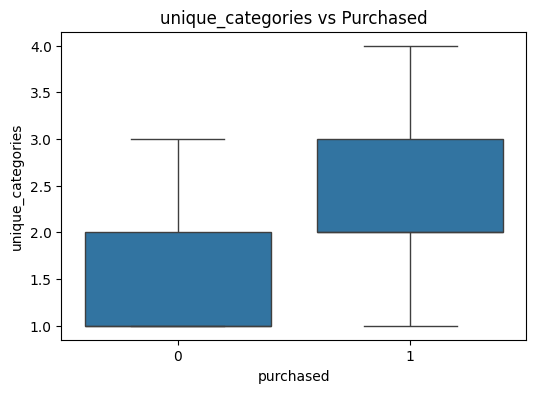

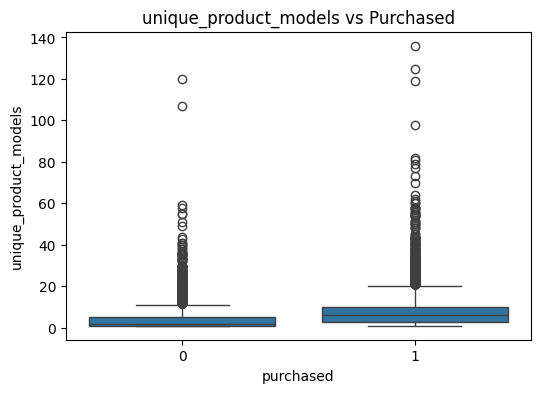

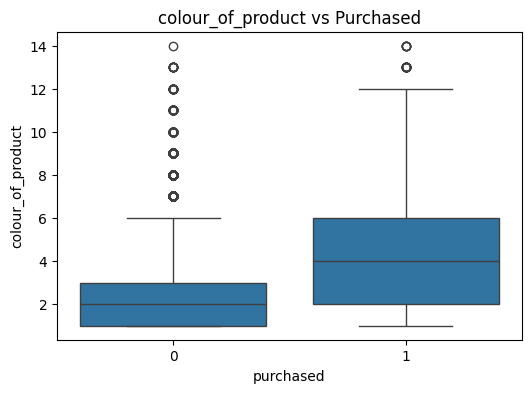

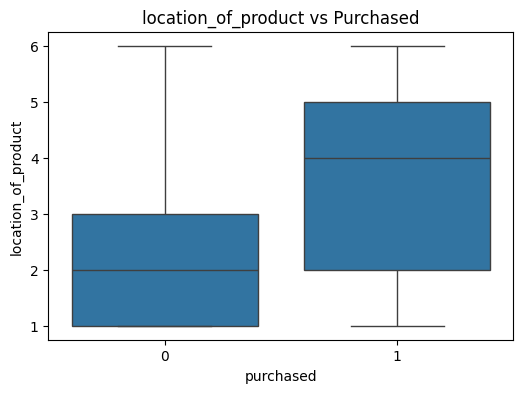

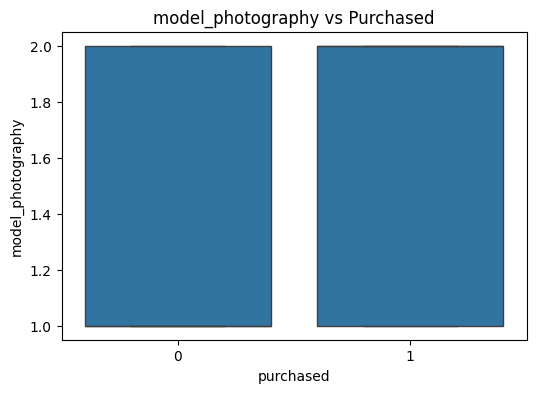

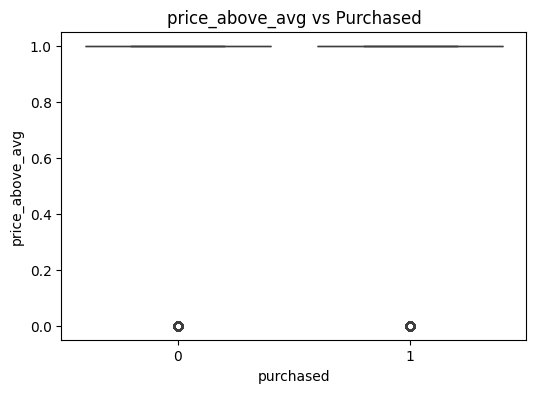

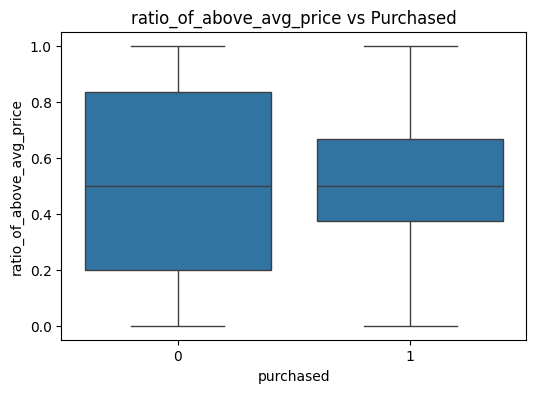

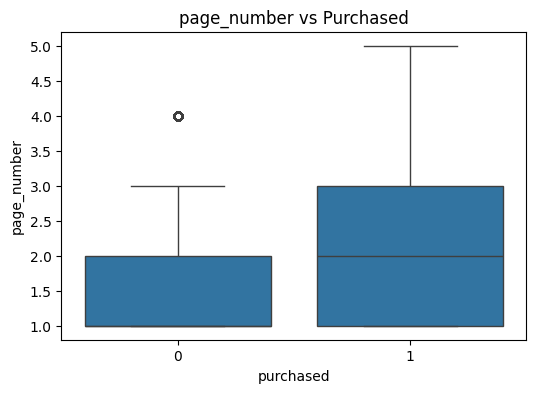

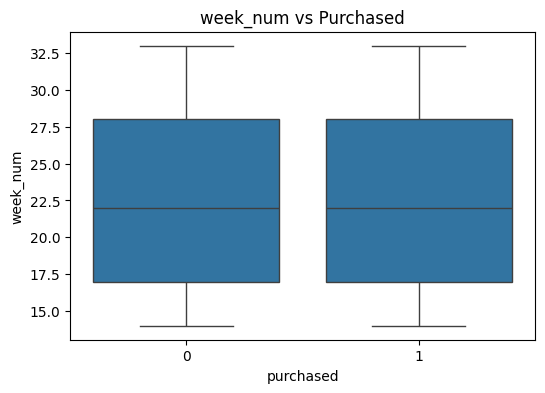

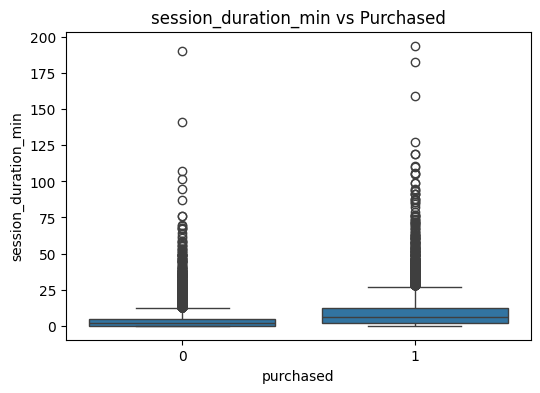

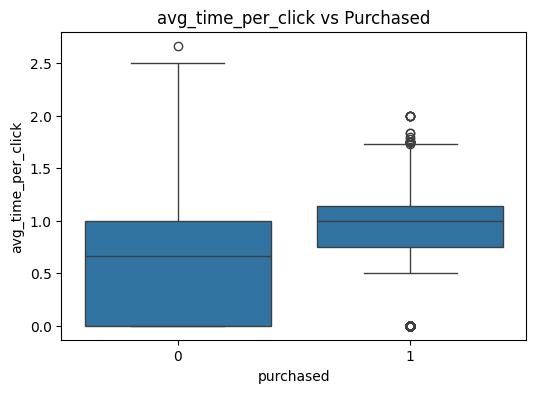

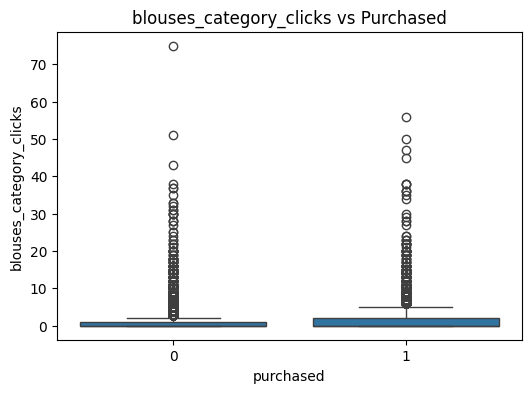

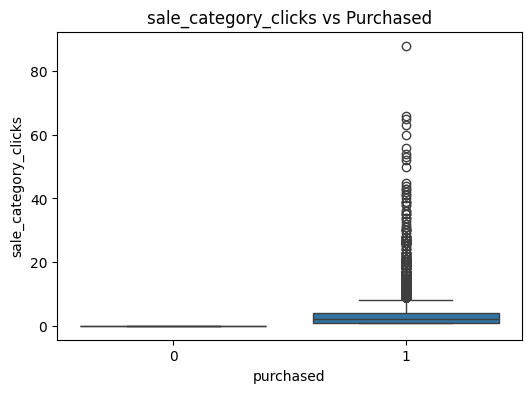

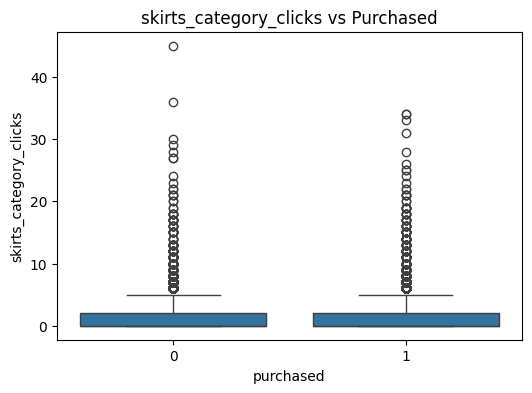

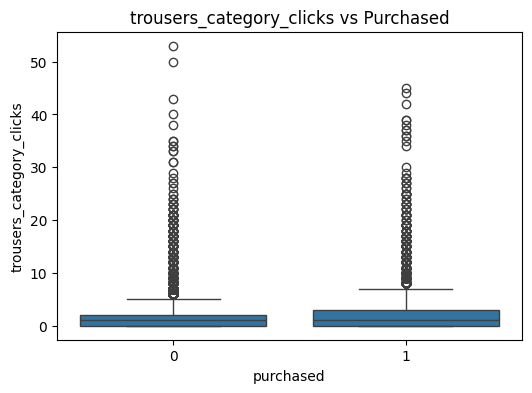

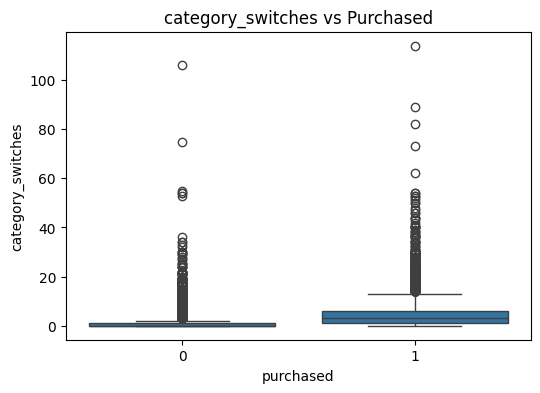

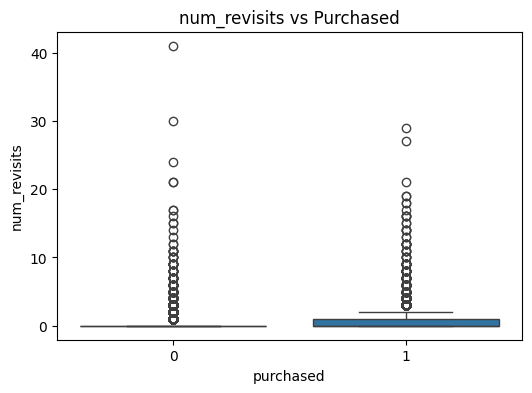

In [17]:
num_features = ['num_of_clicks','Total_revenue','unique_categories','unique_product_models','colour_of_product','location_of_product',
                'model_photography','price_above_avg','ratio_of_above_avg_price','page_number','week_num','session_duration_min','avg_time_per_click',
                'blouses_category_clicks','sale_category_clicks','skirts_category_clicks','trousers_category_clicks','category_switches','num_revisits']

for col in num_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='purchased', y=col, data=session_data)
    plt.title(f"{col} vs Purchased")
    plt.show()

In [18]:
cluster_features = [
    'num_of_clicks','Total_revenue','unique_product_models','num_revisits',
    'session_duration_min','is_weekend','is_end_of_month',
    'blouses_category_clicks','sale_category_clicks','skirts_category_clicks','trousers_category_clicks'
]

X_cluster = session_data[cluster_features].copy()

# Cluster with k=2
cluster_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=2, random_state=42, n_init=10))
])

# Fit and predict clusters
cluster_labels = cluster_pipeline.fit_predict(X_cluster)
session_data['cluster_label'] = cluster_labels

# Calculate silhouette score
sil_score = silhouette_score(X_cluster, cluster_labels)
print(f"Silhouette Score for k=2: {sil_score:.3f}")

# Print cluster means
print("\nCluster means:")
print(session_data.groupby('cluster_label')[cluster_features].mean())

Silhouette Score for k=2: 0.759

Cluster means:
               num_of_clicks  Total_revenue  unique_product_models  \
cluster_label                                                        
0                   4.126964     181.940992               3.892374   
1                  23.733436    1024.781202              20.312275   

               num_revisits  session_duration_min  is_weekend  \
cluster_label                                                   
0                  0.204066              3.758998    0.213213   
1                  2.484335             27.883924    0.208526   

               is_end_of_month  blouses_category_clicks  sale_category_clicks  \
cluster_label                                                                   
0                     0.179708                 0.925184              0.884669   
1                     0.176168                 5.920904              6.536210   

               skirts_category_clicks  trousers_category_clicks  
cluster_label      

In [19]:
print("\nCluster counts:")
print(session_data['cluster_label'].value_counts())


Cluster counts:
cluster_label
0    20116
1     1947
Name: count, dtype: int64


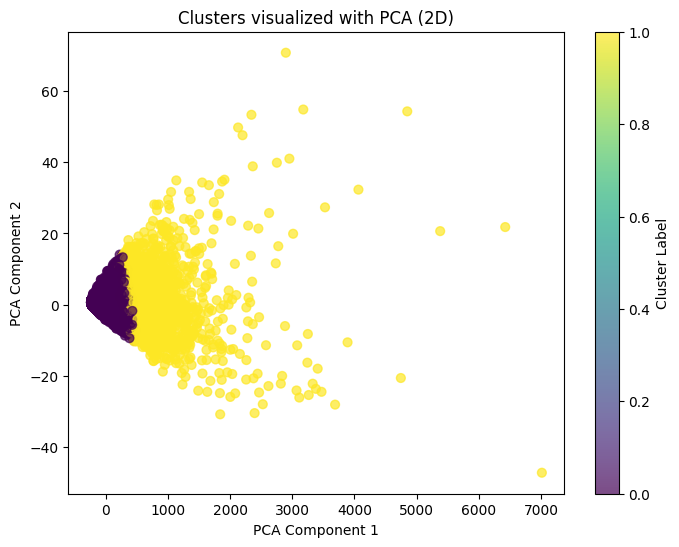


Explained variance ratio (PCA components): [9.99714008e-01 1.11211694e-04]


In [20]:

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=session_data['cluster_label'], alpha=0.7, s=40
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Clusters visualized with PCA (2D)")
plt.colorbar(label="Cluster Label")
plt.show()

print("\nExplained variance ratio (PCA components):", pca.explained_variance_ratio_)

In [21]:
import pickle

with open("models/clustering.pkl", "wb") as f:
    pickle.dump(cluster_pipeline, f)

In [22]:
with open('models/cluster_features.json','w') as f:
    json.dump(cluster_features, f)

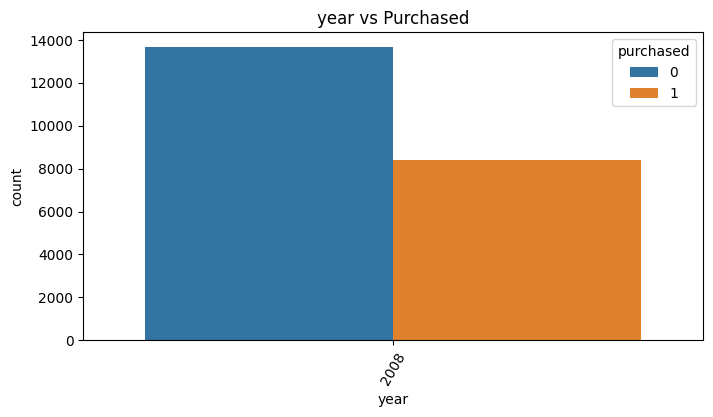

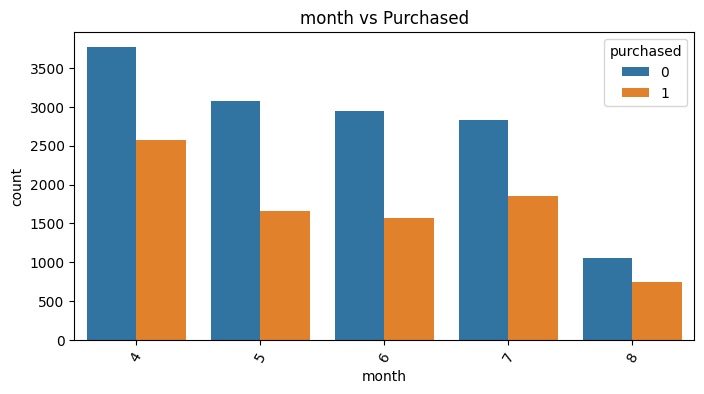

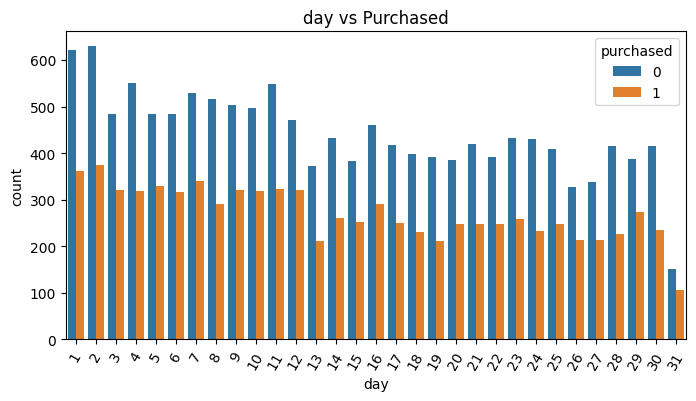

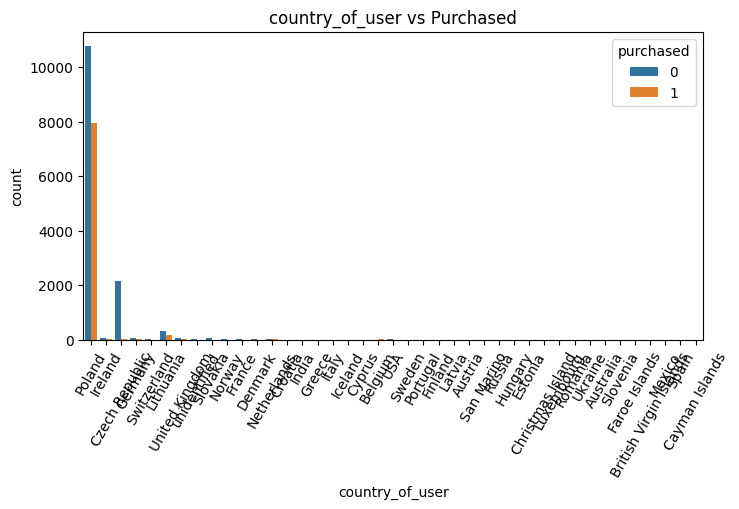

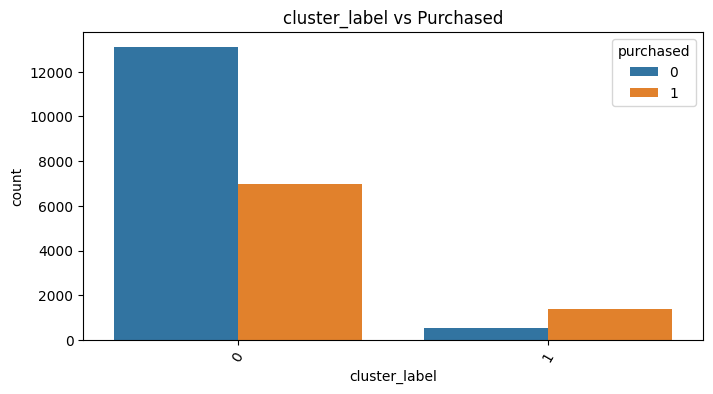

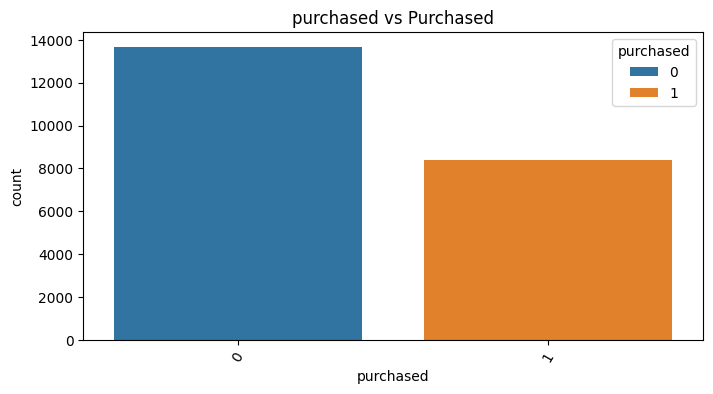

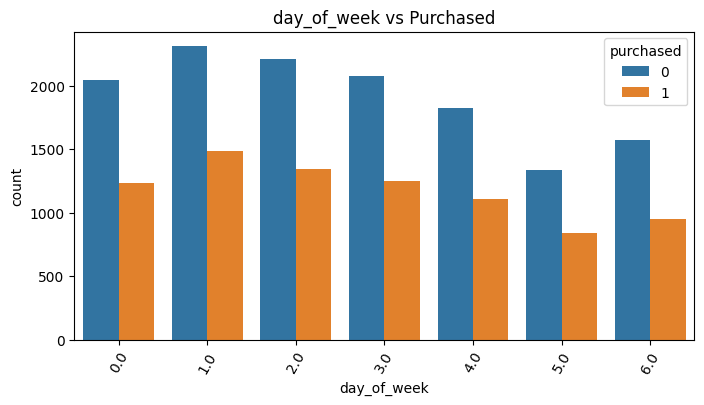

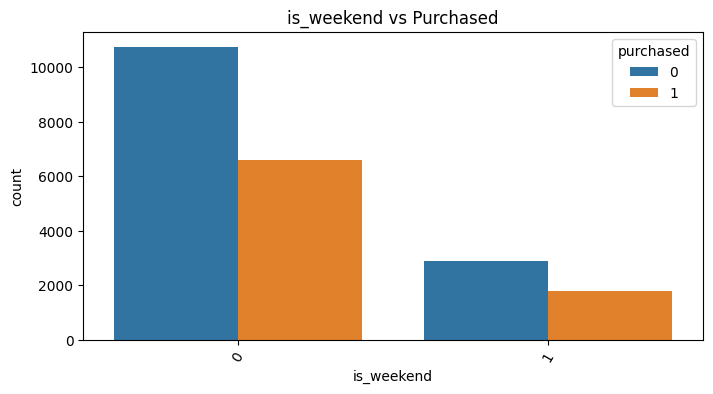

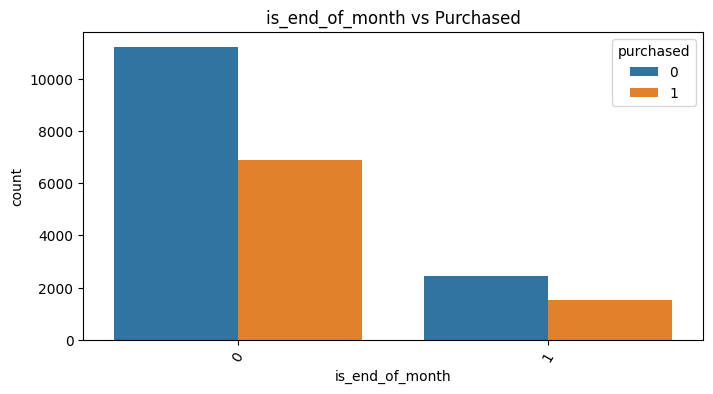

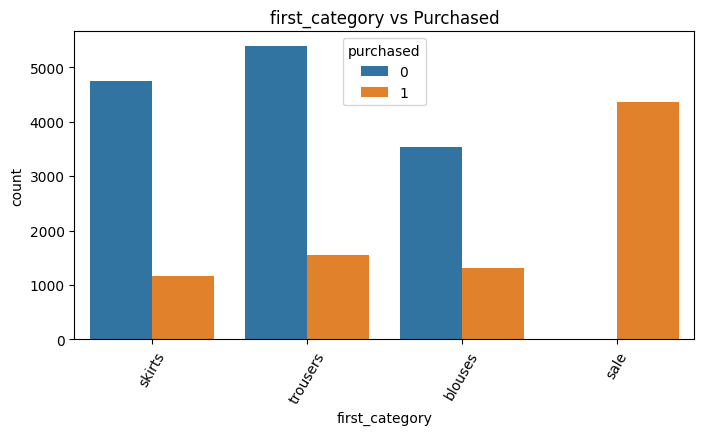

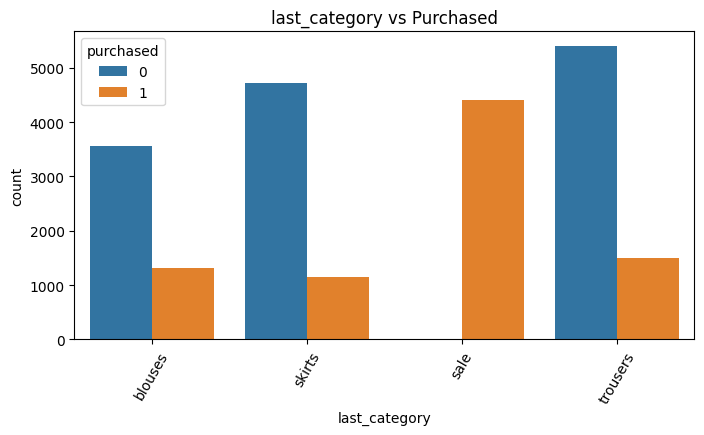

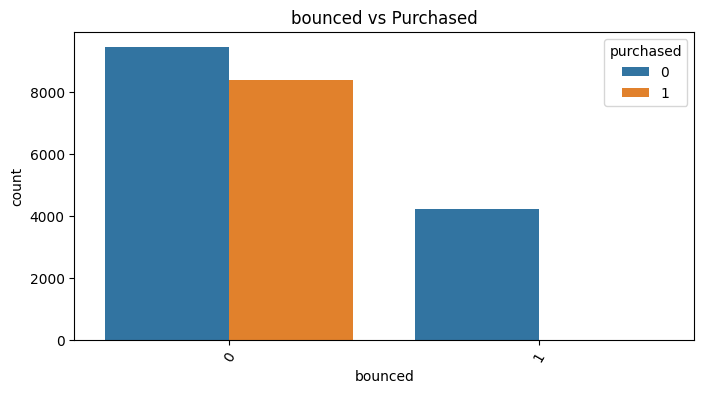

In [23]:
cat_features = ['year','month','day','country_of_user','cluster_label','purchased',
                'day_of_week','is_weekend','is_end_of_month','first_category','last_category','bounced']

for col in cat_features:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='purchased', data=session_data)
    plt.title(f"{col} vs Purchased")
    plt.xticks(rotation=60)
    plt.show()

In [24]:
session_data.to_csv("data/df_for_visuals.csv", index=False)

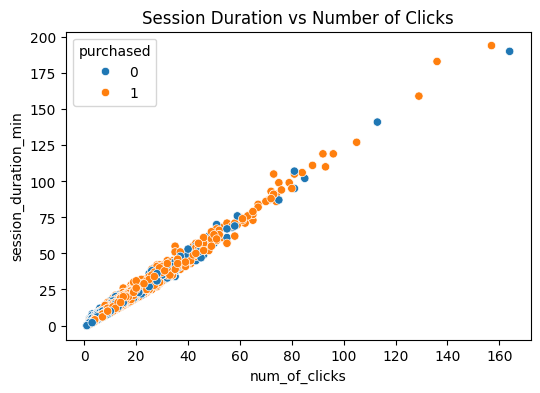

In [25]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='num_of_clicks', y='session_duration_min', hue='purchased', data=session_data)
plt.title("Session Duration vs Number of Clicks")
plt.show()


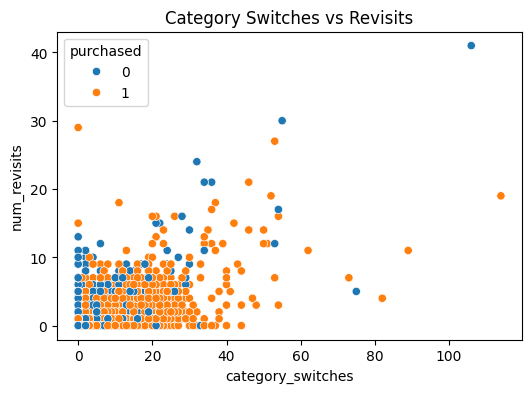

In [26]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='category_switches', y='num_revisits', hue='purchased', data=session_data)
plt.title("Category Switches vs Revisits")
plt.show()

In [27]:
session_data.head(2)

,session_id,num_of_clicks,Total_revenue,year,month,day,country_of_user,unique_categories,unique_product_models,colour_of_product,location_of_product,model_photography,price_above_avg,ratio_of_above_avg_price,page_number,purchased,date,day_of_week,is_weekend,is_end_of_month,week_num,session_duration_min,bounced,avg_time_per_click,blouses_category_clicks,sale_category_clicks,skirts_category_clicks,trousers_category_clicks,first_category,category_switches,last_category,num_revisits,cluster_label
0,1,8,351,2008,4,1,Poland,4,8,6,6,2,1,0.625000,3,1,2008-06-22,6.0,1,0,25,7.0,0,0.875,2,2,3,1,skirts,5,blouses,0.0,0
1,2,9,443,2008,4,1,Poland,3,8,5,6,2,1,0.777778,2,1,2008-05-19,0.0,0,0,21,9.0,0,1.000,0,3,4,2,trousers,5,skirts,1.0,0


In [28]:
# dropping the unwanted features, those that are directly related to the target
session_data = session_data.drop(['session_id','year','unique_categories', 'location_of_product', 'date', 'colour_of_product', 'trousers_category_clicks', 'first_category', 'last_category', 'category_switches', 'avg_time_per_click','session_duration_min','num_of_clicks','bounced'],axis=1)

# session_data.corr()['purchased'].sort_values(ascending=False)

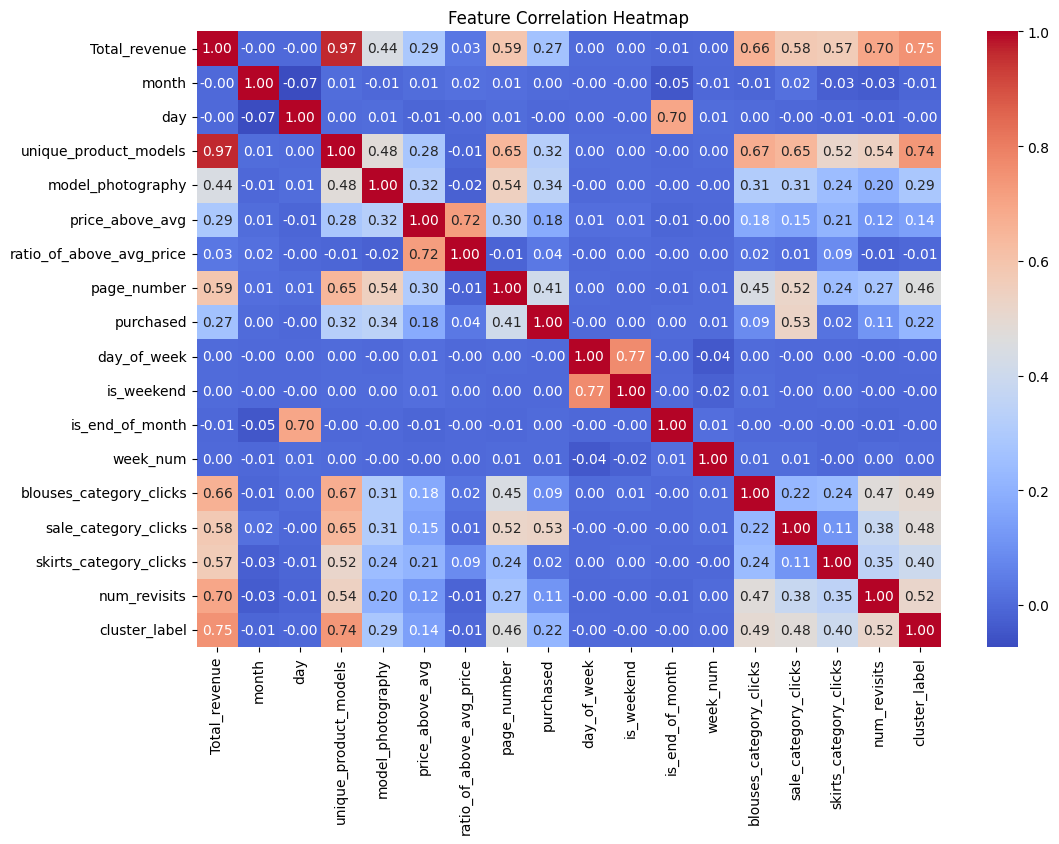

In [29]:
plt.figure(figsize=(12,8))
corr = session_data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


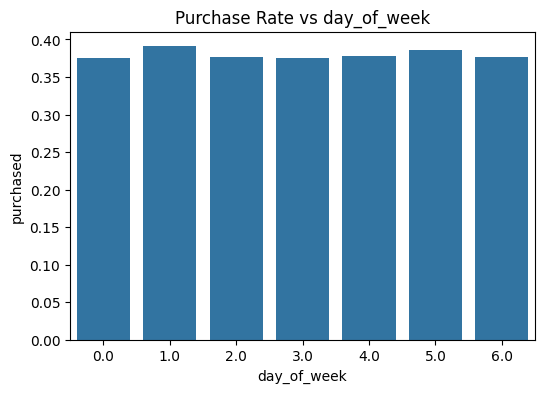

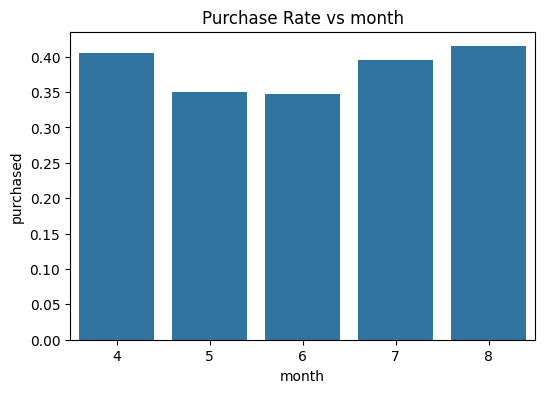

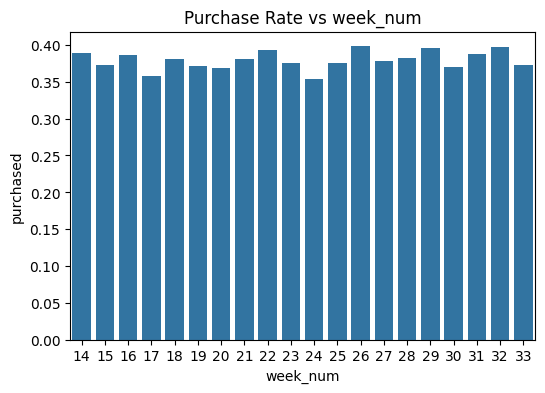

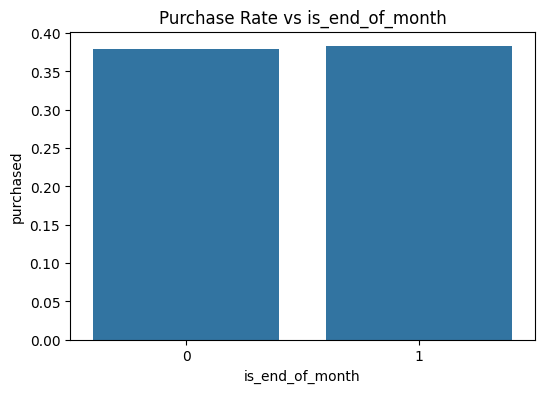

In [30]:
time_features = ['day_of_week','month','week_num','is_end_of_month']

for col in time_features:
    purchase_rate = session_data.groupby(col)['purchased'].mean().reset_index()
    plt.figure(figsize=(6,4))
    sns.barplot(x=col, y='purchased', data=purchase_rate)
    plt.title(f"Purchase Rate vs {col}")
    plt.show()

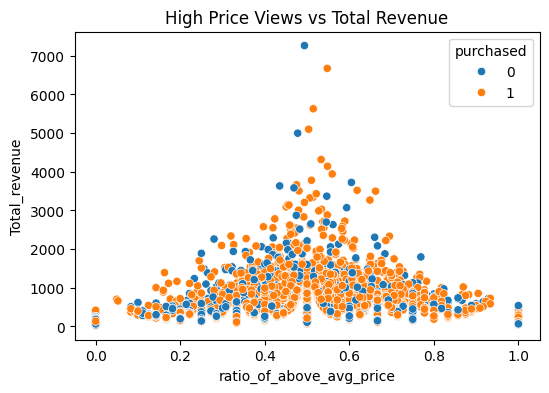

In [31]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='ratio_of_above_avg_price', y='Total_revenue', hue='purchased', data=session_data)
plt.title("High Price Views vs Total Revenue")
plt.show()

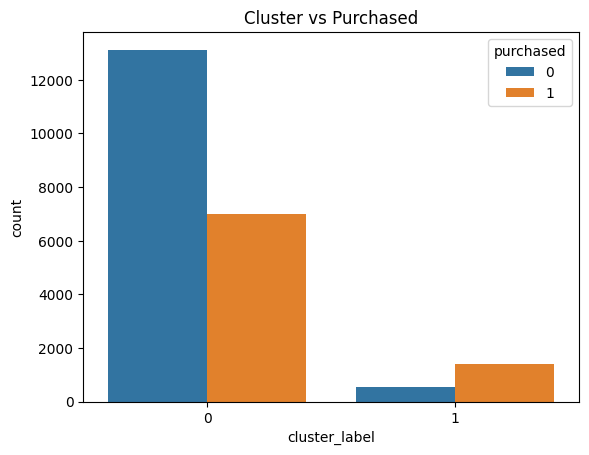

In [32]:
sns.countplot(x='cluster_label', hue='purchased', data=session_data)
plt.title("Cluster vs Purchased")
plt.show()

In [33]:
session_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22063 entries, 0 to 22062
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Total_revenue             22063 non-null  int64  
 1   month                     22063 non-null  int64  
 2   day                       22063 non-null  int64  
 3   country_of_user           22063 non-null  object 
 4   unique_product_models     22063 non-null  int64  
 5   model_photography         22063 non-null  int64  
 6   price_above_avg           22063 non-null  int64  
 7   ratio_of_above_avg_price  22063 non-null  float64
 8   page_number               22063 non-null  int64  
 9   purchased                 22063 non-null  int64  
 10  day_of_week               21564 non-null  float64
 11  is_weekend                22063 non-null  int64  
 12  is_end_of_month           22063 non-null  int64  
 13  week_num                  21564 non-null  UInt32 
 14  blouse

In [34]:
session_data = session_data.drop(['price_above_avg','ratio_of_above_avg_price','day_of_week','is_weekend','is_end_of_month','week_num','cluster_label'],axis=1)

session_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22063 entries, 0 to 22062
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Total_revenue            22063 non-null  int64  
 1   month                    22063 non-null  int64  
 2   day                      22063 non-null  int64  
 3   country_of_user          22063 non-null  object 
 4   unique_product_models    22063 non-null  int64  
 5   model_photography        22063 non-null  int64  
 6   page_number              22063 non-null  int64  
 7   purchased                22063 non-null  int64  
 8   blouses_category_clicks  22063 non-null  int64  
 9   sale_category_clicks     22063 non-null  int64  
 10  skirts_category_clicks   22063 non-null  int64  
 11  num_revisits             22063 non-null  float64
dtypes: float64(1), int64(10), object(1)
memory usage: 2.0+ MB


In [35]:
session_data['purchased'].value_counts()

purchased
0    13674
1     8389
Name: count, dtype: int64

In [ ]:
cls_features = [
    'month','day','country_of_user','model_photography','page_number',
    'unique_product_models','blouses_category_clicks','skirts_category_clicks','num_revisits'
]

In [37]:
X = session_data[cls_features]
y = session_data['purchased']

In [38]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Original Training Class Distribution:")
print(y_train.value_counts(normalize=True))


Original Training Class Distribution:
purchased
0    0.619773
1    0.380227
Name: proportion, dtype: float64


In [39]:
print(X_train.dtypes.value_counts())


int64      7
object     1
float64    1
Name: count, dtype: int64


In [40]:
# NOT NEEDED BECAUSE WE CAN APPLY SMOTE IN MODEL FITTING

# X_train = X_train.astype('float32')

# smote = SMOTE(random_state=42)

# # Only apply on training data
# X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# print("After SMOTE:")
# print(y_train_smote.value_counts(normalize=True))


In [41]:
categorical_cols = [
    'month', 'day', 
    'country_of_user', 'page_number'
]

numerical_cols = [
    'model_photography', 'unique_product_models', 'blouses_category_clicks', 
    'skirts_category_clicks', 'num_revisits'
]

categorical_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
numerical_transformer = StandardScaler()

cls_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols),
        ('num', numerical_transformer, numerical_cols)
    ]
)


In [42]:


lr_pipeline = IMBPipeline([
    ("preprocessor", cls_preprocessor), 
    ('smote', SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=100))
])

lr_pipeline.fit(X_train, y_train)

y_pred = lr_pipeline.predict(X_test)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[2165  570]
 [ 499 1179]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80      2735
           1       0.67      0.70      0.69      1678

    accuracy                           0.76      4413
   macro avg       0.74      0.75      0.75      4413
weighted avg       0.76      0.76      0.76      4413



c:\Users\ishaa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:

dt_pipeline = IMBPipeline(steps=[
    ('preprocessor', cls_preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

y_pred = dt_pipeline.predict(X_test)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Confusion Matrix:
 [[2157  578]
 [ 609 1069]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.79      0.78      2735
           1       0.65      0.64      0.64      1678

    accuracy                           0.73      4413
   macro avg       0.71      0.71      0.71      4413
weighted avg       0.73      0.73      0.73      4413



In [44]:

rf_pipeline = IMBPipeline([
    ('preprocessor', cls_preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=150,n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[2104  631]
 [ 507 1171]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      2735
           1       0.65      0.70      0.67      1678

    accuracy                           0.74      4413
   macro avg       0.73      0.73      0.73      4413
weighted avg       0.75      0.74      0.74      4413



In [45]:

xgb_pipeline = IMBPipeline([
    ('preprocessor', cls_preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(scale_pos_weight=3, random_state=42, eval_metric='logloss', n_estimators=150, n_jobs=-1))
])

xgb_pipeline.fit(X_train, y_train)

y_pred = xgb_pipeline.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[1628 1107]
 [ 114 1564]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.60      0.73      2735
           1       0.59      0.93      0.72      1678

    accuracy                           0.72      4413
   macro avg       0.76      0.76      0.72      4413
weighted avg       0.80      0.72      0.72      4413



In [46]:

models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds)
    print(f"{name} F1 Score: {f1:.4f}")


c:\Users\ishaa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression F1 Score: 0.6881
Decision Tree F1 Score: 0.6430
Random Forest F1 Score: 0.6730
XGBoost F1 Score: 0.7192


In [47]:
with open('models/classification.pkl', 'wb') as f:
    pickle.dump(xgb_pipeline, f)

In [48]:
cls_features = ['month', 'day', 'country_of_user', 'model_photography', 
                'page_number', 'unique_product_models', 
                'blouses_category_clicks', 'skirts_category_clicks', 'num_revisits']

reg_features = cls_features.copy()

with open('models/cls_features.json','w') as f:
    json.dump(cls_features, f)
with open('models/reg_features.json','w') as f:
    json.dump(reg_features, f)

# Regression

X_reg = session_data[reg_features]
y_reg = session_data['Total_revenue']

In [49]:
X_reg = session_data[reg_features]
y_reg = session_data['Total_revenue']

In [50]:
session_data.head()

,Total_revenue,month,day,country_of_user,unique_product_models,model_photography,page_number,purchased,blouses_category_clicks,sale_category_clicks,skirts_category_clicks,num_revisits
0,351,4,1,Poland,8,2,3,1,2,2,3,0.0
1,443,4,1,Poland,8,2,2,1,0,3,4,1.0
2,134,4,1,Ireland,3,2,1,0,2,0,1,0.0
3,181,4,1,Ireland,4,1,3,0,2,0,0,0.0
4,57,4,1,Czech Republic,1,1,1,0,1,0,0,0.0


In [51]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


In [52]:
def make_regression_pipeline(model):
    return IMBPipeline(steps=[
        ('preprocessor', cls_preprocessor),
        ('regressor', model)
    ])

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1)
}

In [53]:
def evaluate_regression(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"--- {model_name} ---")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)

    plt.figure(figsize=(5,4))
    plt.scatter(y_test, y_pred, alpha=0.4)
    plt.xlabel("Actual Revenue")
    plt.ylabel("Predicted Revenue")
    plt.title(f"{model_name}: Actual vs Predicted")
    plt.grid(True)
    plt.show()

--- Linear Regression ---
MAE : 25.592514300153415
MSE : 1867.0028096756578
RMSE: 43.20882791369905
R²  : 0.9781520708814633


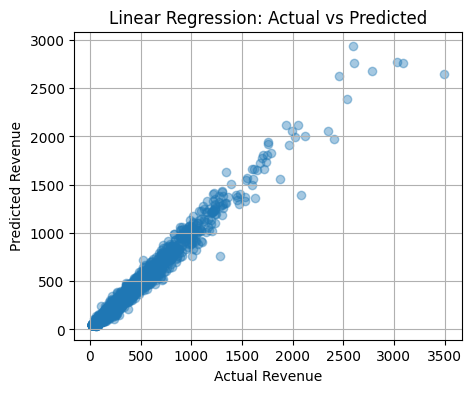

--- Decision Tree ---
MAE : 34.59390431311708
MSE : 3675.315711482387
RMSE: 60.624382153407446
R²  : 0.956990939308409


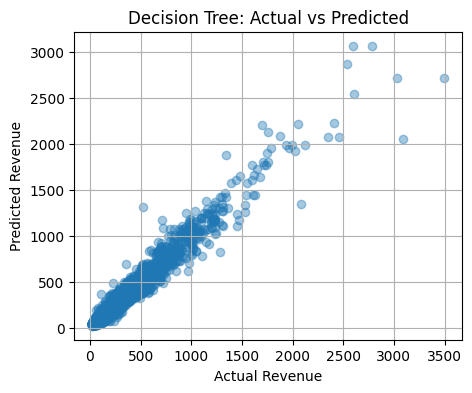

--- Random Forest ---
MAE : 26.349570800688532
MSE : 2047.1725379317008
RMSE: 45.245690821687106
R²  : 0.976043699414723


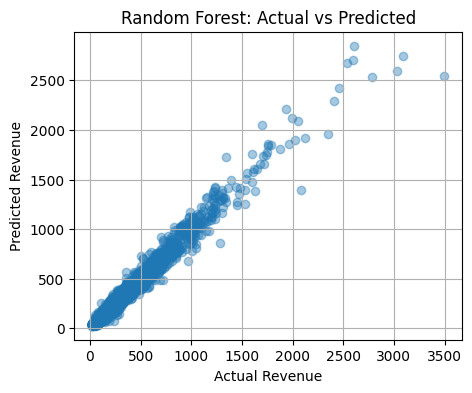

--- XGBoost ---
MAE : 24.782791137695312
MSE : 1846.697265625
RMSE: 42.97321567703539
R²  : 0.9783896803855896


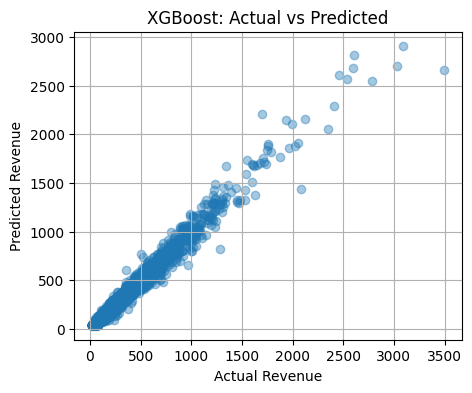

In [54]:
for name, reg in models.items():
    pipe = make_regression_pipeline(reg)
    pipe.fit(X_train_reg, y_train_reg)
    evaluate_regression(pipe, X_test_reg, y_test_reg, name)

--- XGBoost ---
MAE : 24.782791137695312
MSE : 1846.697265625
RMSE: 42.97321567703539
R²  : 0.9783896803855896


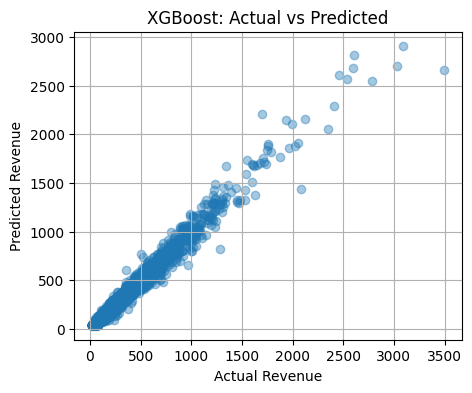

In [55]:
reg_pipeline = make_regression_pipeline(models["XGBoost"])
reg_pipeline.fit(X_train_reg, y_train_reg)
evaluate_regression(reg_pipeline, X_test_reg, y_test_reg, "XGBoost")

In [56]:

with open("models/regression.pkl", "wb") as f:
    pickle.dump(reg_pipeline, f)